**Import Libraries & Read Data**

In [6]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from wordcloud import WordCloud
from nltk.corpus import stopwords
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import pickle as pk
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [7]:
# Download NLTK data
import nltk
nltk.download('stopwords')
print("NLTK stopwords downloaded successfully!")

NLTK stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\abdbl\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
fake = pd.read_csv('dataset/Fake.csv')
real = pd.read_csv('dataset/True.csv')
fake["Label"], real["Label"] = "F","R"
data = pd.concat([fake,real],axis=0)
data.head()

,title,text,subject,date,Label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",F
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",F
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",F
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",F
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",F


**Data Exploration**

In [9]:
#Shape Of Data
data.shape

(44898, 5)

In [10]:
#Info Of Data
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 21416
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   Label    44898 non-null  object
dtypes: object(5)
memory usage: 2.1+ MB


In [11]:
#NULL Data
data.isna().sum()

title      0
text       0
subject    0
date       0
Label      0
dtype: int64

In [12]:
data.describe(include='object').transpose()

,count,unique,top,freq
title,44898,38729,Factbox: Trump fills top jobs for his administ...,14
text,44898,38646,,627
subject,44898,8,politicsNews,11272
date,44898,2397,"December 20, 2017",182
Label,44898,2,F,23481


In [13]:
data[data.duplicated(keep=False)]

,title,text,subject,date,Label
9941,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017",F
9942,HILLARY TWEETS MESSAGE In Defense Of DACA…OOPS...,No time to waste we've got to fight with eve...,politics,"Sep 9, 2017",F
11445,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017",F
11446,FORMER DEMOCRAT WARNS Young Americans: “Rioter...,"Who is silencing political speech, physically...",politics,"Mar 10, 2017",F
14924,[VIDEO] #BlackLivesMatter Terrorists Storm Dar...,They were probably just looking for a safe sp...,politics,"Nov 16, 2015",F
...,...,...,...,...,...
21290,"Europeans, Africans agree renewed push to tack...",PARIS (Reuters) - Europe s big four continen...,worldnews,"August 28, 2017",R
21345,Thailand's ousted PM Yingluck has fled abroad:...,BANGKOK (Reuters) - Ousted Thai prime minister...,worldnews,"August 25, 2017",R
21353,Thailand's ousted PM Yingluck has fled abroad:...,BANGKOK (Reuters) - Ousted Thai prime minister...,worldnews,"August 25, 2017",R
21406,"U.S., North Korea clash at U.N. forum over nuc...",GENEVA (Reuters) - North Korea and the United ...,worldnews,"August 22, 2017",R


In [14]:
data.Label.value_counts()

Label
F    23481
R    21417
Name: count, dtype: int64

C:\Users\abdbl\AppData\Local\Temp\ipykernel_31448\2895520974.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Label',data=data,palette='Blues')


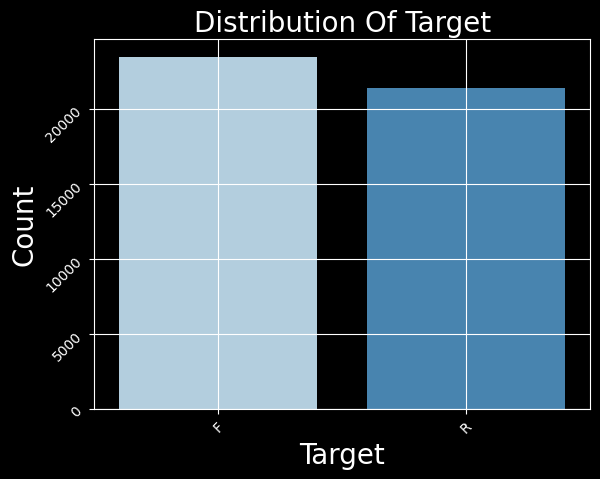

In [15]:
sns.countplot(x='Label',data=data,palette='Blues')
plt.title('Distribution Of Target',fontsize=20)
plt.xlabel('Target',fontsize=20)
plt.ylabel('Count',fontsize=20)
plt.grid(True)
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

In [16]:
data.subject.value_counts()

subject
politicsNews       11272
worldnews          10145
News                9050
politics            6841
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64

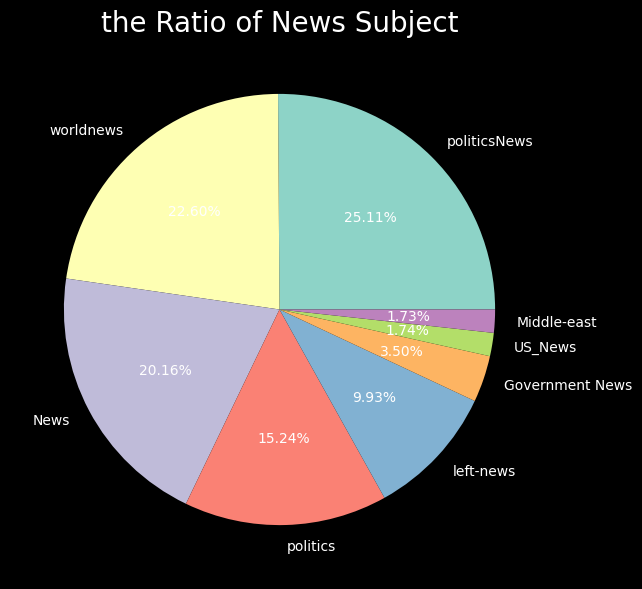

In [17]:
plt.figure(figsize=(7,7))
plt.pie(x = data['subject'].value_counts() ,autopct='%1.2f%%' ,labels=data['subject'].value_counts().index)
plt.title('the Ratio of News Subject',fontsize=20)
plt.show()

In [18]:
counts = data.groupby(['subject', 'Label']).size().unstack(fill_value=0)
counts

Label,F,R
subject,,
Government News,1570,0
Middle-east,778,0
News,9050,0
US_News,783,0
left-news,4459,0
politics,6841,0
politicsNews,0,11272
worldnews,0,10145


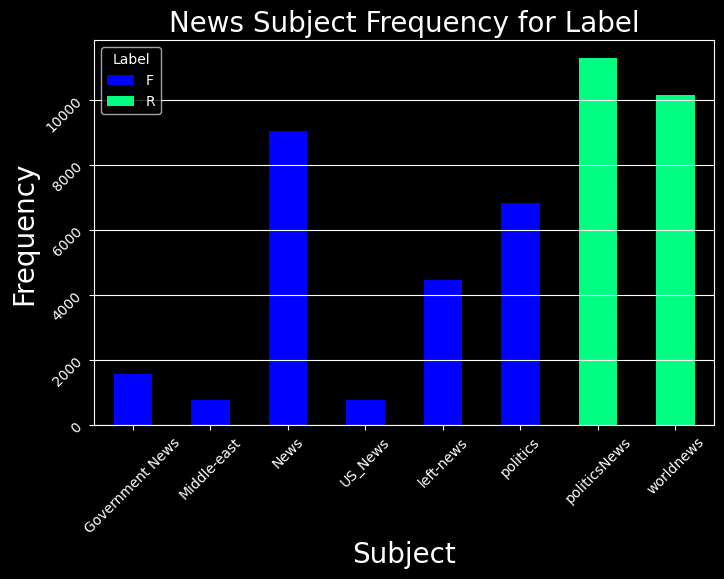

In [19]:
plt.figure(figsize=(8,5))
counts.plot(kind='bar', stacked=True, colormap="winter", ax=plt.gca())
plt.title('News Subject Frequency for Label', fontsize=20)
plt.xlabel('Subject', fontsize=20)
plt.ylabel('Frequency', fontsize=20)
plt.grid(True, axis="y")
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.show()

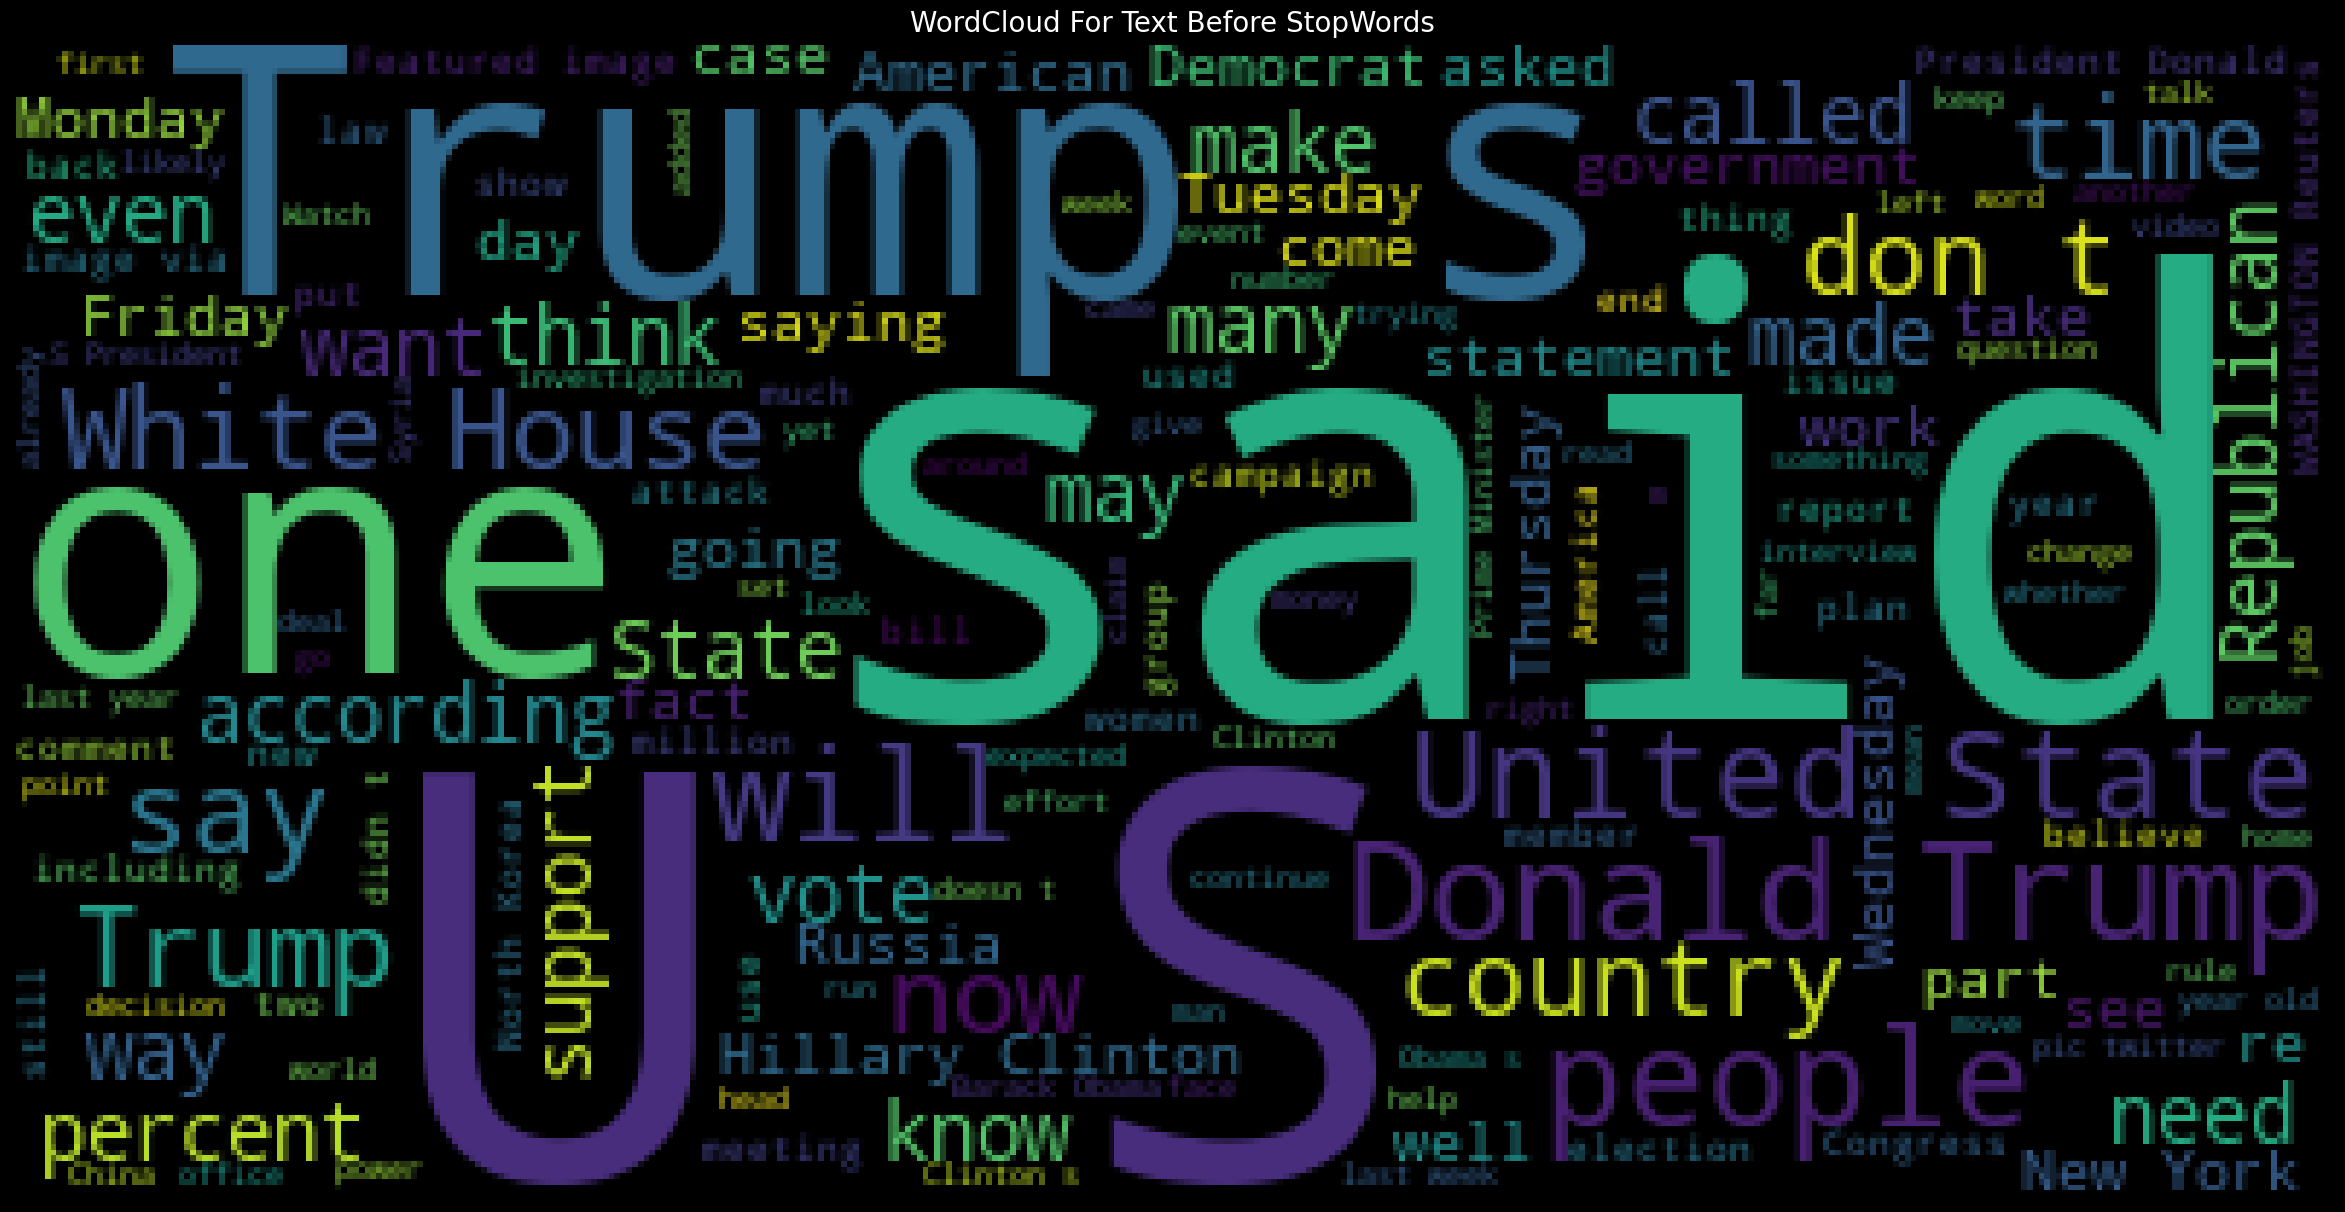

In [20]:
plt.figure(figsize=(30,20))
plt.imshow(WordCloud(background_color = 'black').generate(" ".join(data.text)))
plt.axis("off")
plt.title("WordCloud For Text Before StopWords",fontsize=20)
plt.show()   

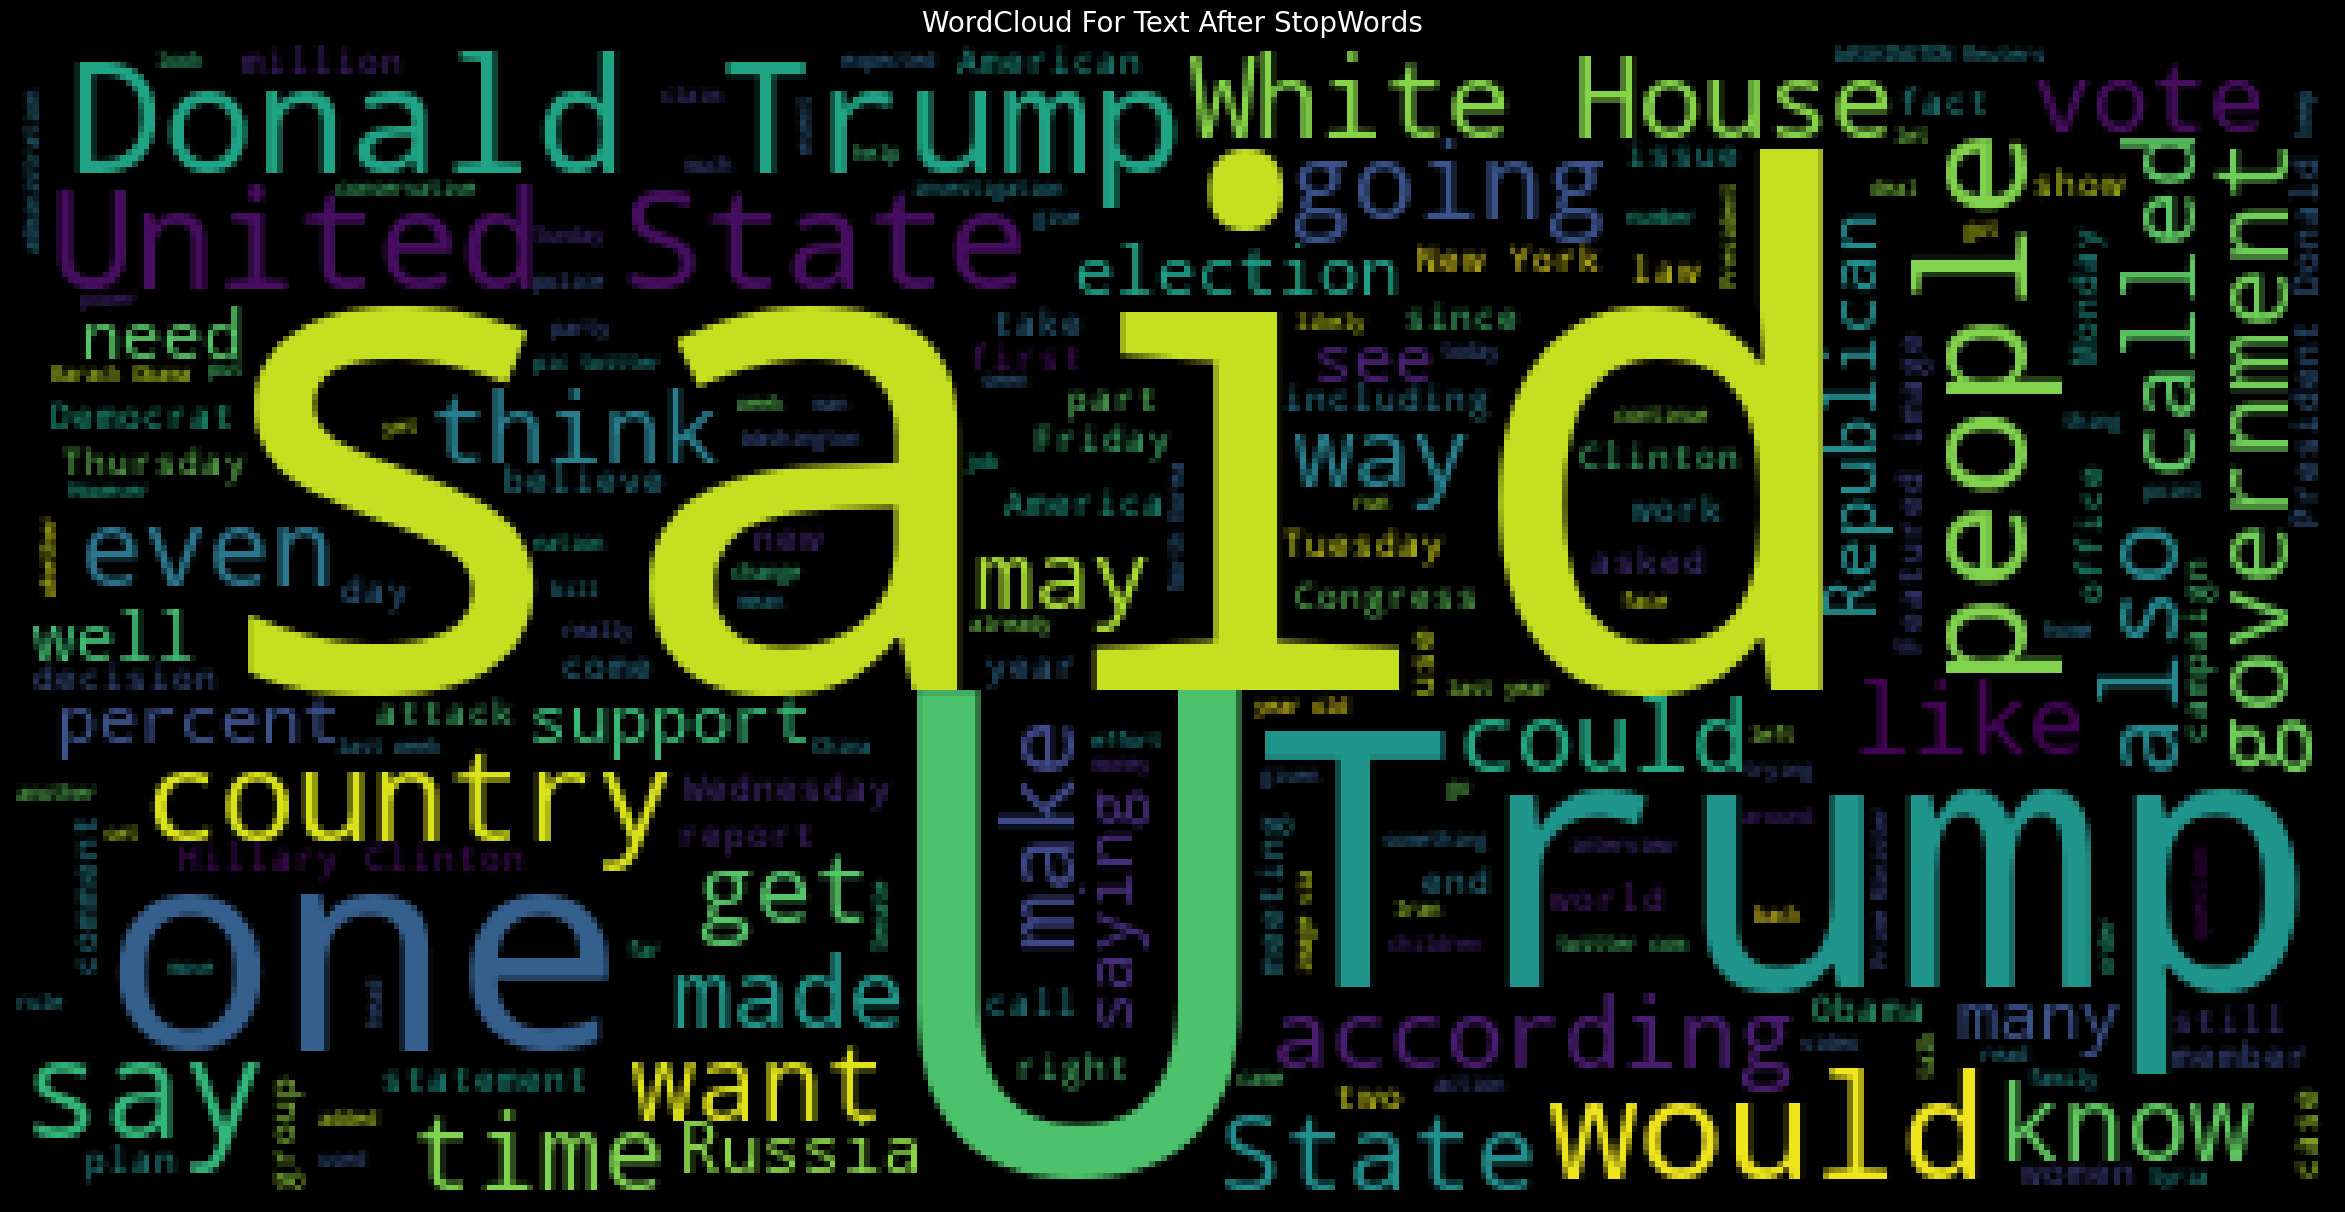

In [21]:
plt.figure(figsize=(30,20))
plt.imshow(WordCloud(background_color = 'black',stopwords=set(stopwords.words('english'))).generate(" ".join(data.text)))
plt.axis("off")
plt.title("WordCloud For Text After StopWords",fontsize=20)
plt.show()  

**Model Building**

In [22]:
#Input
Text = data.text
Text

0        Donald Trump just couldn t wish all Americans ...
1        House Intelligence Committee Chairman Devin Nu...
2        On Friday, it was revealed that former Milwauk...
3        On Christmas day, Donald Trump announced that ...
4        Pope Francis used his annual Christmas Day mes...
                               ...                        
21412    BRUSSELS (Reuters) - NATO allies on Tuesday we...
21413    LONDON (Reuters) - LexisNexis, a provider of l...
21414    MINSK (Reuters) - In the shadow of disused Sov...
21415    MOSCOW (Reuters) - Vatican Secretary of State ...
21416    JAKARTA (Reuters) - Indonesia will buy 11 Sukh...
Name: text, Length: 44898, dtype: object

In [23]:
def clean_text(text):
    # Remove Twitter handles starting with '@'
    text = re.sub(r'@\w+', '', text)
    # Remove non-alphanumeric characters and extra whitespace
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Convert multiple whitespace characters to a single space
    text = re.sub(r'\s+', ' ', text)
    # Convert the text to lowercase
    text = text.lower()
    return text

In [24]:
Text = Text.apply(clean_text)
Text

0        donald trump just couldn t wish all americans ...
1        house intelligence committee chairman devin nu...
2        on friday it was revealed that former milwauke...
3        on christmas day donald trump announced that h...
4        pope francis used his annual christmas day mes...
                               ...                        
21412    brussels reuters nato allies on tuesday welcom...
21413    london reuters lexisnexis a provider of legal ...
21414    minsk reuters in the shadow of disused soviete...
21415    moscow reuters vatican secretary of state card...
21416    jakarta reuters indonesia will buy sukhoi figh...
Name: text, Length: 44898, dtype: object

In [25]:
#Output
Target = data.Label
Target

0        F
1        F
2        F
3        F
4        F
        ..
21412    R
21413    R
21414    R
21415    R
21416    R
Name: Label, Length: 44898, dtype: object

In [26]:
#Transform Output
Target.replace('R',1,inplace=True)
Target.replace('F',0,inplace=True)
Target

0        0
1        0
2        0
3        0
4        0
        ..
21412    1
21413    1
21414    1
21415    1
21416    1
Name: Label, Length: 44898, dtype: int64

In [27]:
vectorizer = TfidfVectorizer()
Text= vectorizer.fit_transform(Text)

# Save the vectorizer for later use
pk.dump(vectorizer, open('models/tfidf_vectorizer.sav', 'wb'))
print("TF-IDF Vectorizer saved successfully!")

TF-IDF Vectorizer saved successfully!


In [28]:
#Split Data
X_train,X_test,y_train,y_test = train_test_split(Text,Target,test_size=.15,shuffle=True,random_state=44)
print('X_train Shape :',X_train.shape)
print('X_test Shape :',X_test.shape)
print('y_train Shape :',y_train.shape)
print('y_test Shape :',y_test.shape)

X_train Shape : (38163, 204588)
X_test Shape : (6735, 204588)
y_train Shape : (38163,)
y_test Shape : (6735,)


### RandomForestClassifier

In [29]:
#Model
model = Pipeline([
    #('tfid',TfidfVectorizer()),
    ('model',RandomForestClassifier(criterion = 'gini',n_estimators=400,max_depth=600,random_state=44))
    ])
model.fit(X_train,y_train)

Pipeline(steps=[('model',
                 RandomForestClassifier(max_depth=600, n_estimators=400,
                                        random_state=44))])

**Model Check**

In [30]:
print('Pipeline Model Train Score is : ' , model.score(X_train, y_train))
print('Pipeline Model Test Score is : ' , model.score(X_test, y_test))

Pipeline Model Train Score is :  0.9999737966092812
Pipeline Model Test Score is :  0.9925760950259837
Pipeline Model Test Score is :  0.9925760950259837


In [31]:
y_pred = model.predict(X_test)

In [32]:
df = pd.DataFrame()
df['Actual'],df['Predicted'] = y_test,y_pred
df.replace(1,'R',inplace=True)
df.replace(0,'F',inplace=True)
df

,Actual,Predicted
1606,R,R
23233,F,F
6372,R,R
2389,R,R
16982,R,R
...,...,...
1904,R,R
7825,F,F
11369,R,R
7223,F,F


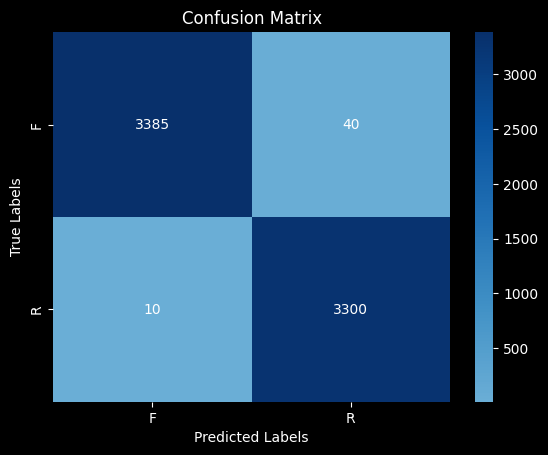

array([[3385,   40],
       [  10, 3300]], dtype=int64)

In [33]:
CM = confusion_matrix(y_test, y_pred)
target_names = ['F','R']
sns.heatmap(CM,annot=True,fmt='g',center = True,cmap='Blues',xticklabels=target_names,yticklabels=target_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
CM

In [34]:
ClassificationReport = classification_report(y_test,y_pred,target_names=target_names)
print('Classification Report is :\n ', ClassificationReport)

Classification Report is :
                precision    recall  f1-score   support

           F       1.00      0.99      0.99      3425
           R       0.99      1.00      0.99      3310

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



**Save Model**

In [35]:
pk.dump(model , open('models/random_forest_model.sav','wb'))
print("Random Forest model saved successfully!")

Random Forest model saved successfully!


In [36]:
saved_model = pk.load(open('models/random_forest_model.sav','rb'))
print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


### LogisticRegression

In [37]:
#Model
model = Pipeline([
    #('tfid',TfidfVectorizer()),
    ('model',LogisticRegression(penalty='l2',solver='sag',C=1.0,random_state=44))
    ])
model.fit(X_train,y_train)

Pipeline(steps=[('model', LogisticRegression(random_state=44, solver='sag'))])

**Model Check**

In [38]:
print('Pipeline Model Train Score is : ' , model.score(X_train, y_train))
print('Pipeline Model Test Score is : ' , model.score(X_test, y_test))

Pipeline Model Train Score is :  0.9930561014595288
Pipeline Model Test Score is :  0.9899034892353378


In [39]:
y_pred = model.predict(X_test)

In [40]:
df = pd.DataFrame()
df['Actual'],df['Predicted'] = y_test,y_pred
df.replace(1,'R',inplace=True)
df.replace(0,'F',inplace=True)
df

,Actual,Predicted
1606,R,R
23233,F,F
6372,R,R
2389,R,R
16982,R,R
...,...,...
1904,R,R
7825,F,F
11369,R,R
7223,F,F


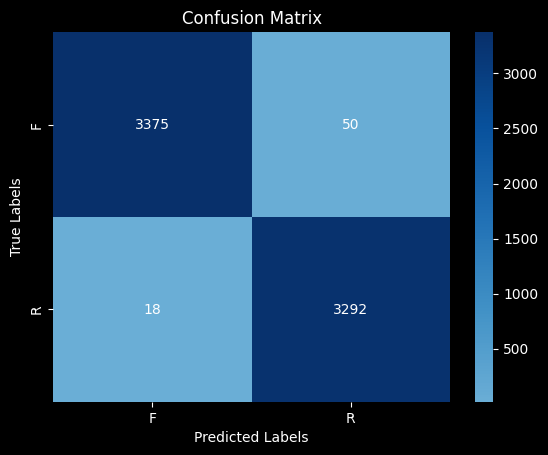

array([[3375,   50],
       [  18, 3292]], dtype=int64)

In [41]:
CM = confusion_matrix(y_test, y_pred)
sns.heatmap(CM,annot=True,fmt='g',center = True,cmap='Blues',xticklabels=target_names,yticklabels=target_names)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
CM

In [42]:
ClassificationReport = classification_report(y_test,y_pred,target_names=target_names)
print('Classification Report is :\n ', ClassificationReport)

Classification Report is :
                precision    recall  f1-score   support

           F       0.99      0.99      0.99      3425
           R       0.99      0.99      0.99      3310

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735



**Save Model**

In [43]:
pk.dump(model , open('models/logistic_regression_model.sav','wb'))
print("Logistic Regression model saved successfully!")

Logistic Regression model saved successfully!


In [44]:
saved_model = pk.load(open('models/logistic_regression_model.sav','rb'))
print("Logistic Regression model loaded successfully!")

Logistic Regression model loaded successfully!


In [45]:
# Utility function for making predictions on new text
def predict_fake_news(text, model_type='random_forest'):
    """
    Predict if a news article is fake or real
    
    Args:
        text (str): The news article text
        model_type (str): 'random_forest' or 'logistic_regression'
    
    Returns:
        dict: Prediction result with confidence
    """
    # Load the saved models
    if model_type == 'random_forest':
        model = pk.load(open('models/random_forest_model.sav', 'rb'))
    else:
        model = pk.load(open('models/logistic_regression_model.sav', 'rb'))
    
    # Load the vectorizer
    vectorizer = pk.load(open('models/tfidf_vectorizer.sav', 'rb'))
    
    # Clean the text
    cleaned_text = clean_text(text)
    
    # Vectorize the text
    text_vectorized = vectorizer.transform([cleaned_text])
    
    # Make prediction
    prediction = model.predict(text_vectorized)[0]
    confidence = model.predict_proba(text_vectorized)[0].max()
    
    # Convert prediction to readable format
    result = "Real" if prediction == 1 else "Fake"
    
    return {
        "prediction": result,
        "confidence": round(confidence * 100, 2),
        "model_used": model_type
    }

# Test the function
sample_text = "This is a test news article about politics."
result = predict_fake_news(sample_text)
print("Sample prediction:", result)

Sample prediction: {'prediction': 'Fake', 'confidence': 93.74, 'model_used': 'random_forest'}
